# Comparación de modelos MLP vs EfficientNetB0

## 1. Configuración y carga de datos

In [1]:
import os
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

IMG_SIZE = 128
BATCH_SIZE = 32

base_dir = 'dataset'
test_dir = os.path.join(base_dir, 'test')

# Generador para EfficientNet (con preprocess_input)
test_datagen_dl = ImageDataGenerator(preprocessing_function=preprocess_input)
test_generator_dl = test_datagen_dl.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Generador para MLP (sin preprocess, solo rescaling a 0-1)
test_datagen_mlp = ImageDataGenerator(rescale=1./255)
test_generator_mlp = test_datagen_mlp.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_names = list(test_generator_dl.class_indices.keys())
print('Clases:', class_names)

I0000 00:00:1774508280.098954    4720 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774508280.974356    4720 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774508283.902787    4720 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Found 1273 images belonging to 10 classes.
Found 1273 images belonging to 10 classes.
Clases: ['carbon', 'hoja_amarilla', 'mancha_anillo', 'mancha_parda', 'mosaico', 'muermo_rojo', 'roya', 'sanas', 'secas', 'tizon_bacteriano']


## 2. Cargar modelos entrenados

In [2]:
mlp_path = 'mlp_best_model.keras'
dl_path = 'modelo_EfficientNetB0.keras'

mlp_model = tf.keras.models.load_model(mlp_path)
dl_model = tf.keras.models.load_model(dl_path)

print('Modelos cargados:')
print(' - MLP:', mlp_path)
print(' - EfficientNetB0:', dl_path)

E0000 00:00:1774508286.631003    4720 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1774508286.631256    5027 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
E0000 00:00:1774508286.645271    4720 cuda_executor.cc:1827] Nvml call failed with 3(Not Supported). Assuming PCIe gen 3 x16 bandwidth.
W0000 00:00:1774508286.645792    4720 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Modelos cargados:
 - MLP: mlp_best_model.keras
 - EfficientNetB0: modelo_EfficientNetB0.keras


## 3. Evaluación en conjunto de prueba

In [4]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

test_generator_mlp.reset()
test_generator_dl.reset()

X_test_mlp = []

for _ in range(int(np.ceil(test_generator_mlp.samples / BATCH_SIZE))):
    x_batch, _ = next(test_generator_mlp)
    X_test_mlp.append(x_batch)

X_test_mlp = np.vstack(X_test_mlp)

y_true = test_generator_dl.classes

mlp_pred = np.argmax(
    mlp_model.predict(X_test_mlp, batch_size=64, verbose=1),
    axis=1
)

test_generator_dl.reset()

dl_pred = np.argmax(
    dl_model.predict(test_generator_dl, verbose=1),
    axis=1
)

mlp_metrics = {
    'accuracy': accuracy_score(y_true, mlp_pred),
    'precision': precision_score(y_true, mlp_pred, average='weighted', zero_division=0),
    'recall': recall_score(y_true, mlp_pred, average='weighted', zero_division=0),
    'f1': f1_score(y_true, mlp_pred, average='weighted', zero_division=0)
}

dl_metrics = {
    'accuracy': accuracy_score(y_true, dl_pred),
    'precision': precision_score(y_true, dl_pred, average='weighted', zero_division=0),
    'recall': recall_score(y_true, dl_pred, average='weighted', zero_division=0),
    'f1': f1_score(y_true, dl_pred, average='weighted', zero_division=0)
}

print('MLP Metrics:', mlp_metrics)
print('EfficientNetB0 Metrics:', dl_metrics)

mlp_cm = confusion_matrix(y_true, mlp_pred)
dl_cm = confusion_matrix(y_true, dl_pred)

print('\nMLP Classification Report:\n')
print(classification_report(y_true, mlp_pred, target_names=class_names, digits=4))

print('\nEfficientNetB0 Classification Report:\n')
print(classification_report(y_true, dl_pred, target_names=class_names, digits=4))

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step


I0000 00:00:1774508694.486772    4720 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


40/40 ━━━━━━━━━━━━━━━━━━━━ 30s 690ms/step
MLP Metrics: {'accuracy': 0.582089552238806, 'precision': 0.5949136514523542, 'recall': 0.582089552238806, 'f1': 0.5630673050574756}
EfficientNetB0 Metrics: {'accuracy': 0.8908091123330715, 'precision': 0.8957927096885065, 'recall': 0.8908091123330715, 'f1': 0.8916130668831707}

MLP Classification Report:

                  precision    recall  f1-score   support

          carbon     0.9722    0.9333    0.9524        75
   hoja_amarilla     0.6090    0.6333    0.6209       150
   mancha_anillo     0.7568    0.5333    0.6257       105
    mancha_parda     0.6022    0.7467    0.6667       150
         mosaico     0.5780    0.4200    0.4865       150
     muermo_rojo     0.4265    0.5800    0.4915       150
            roya     0.3444    0.2067    0.2583       150
           sanas     0.5842    0.7400    0.6529       150
           secas     1.0000    0.0233    0.0455        43
tizon_bacteriano     0.6021    0.7667    0.6745       150

        ac

## 4. Comparación visual de métricas

     Métrica       MLP  EfficientNetB0  Diferencia
0   accuracy  0.582090        0.890809    0.308720
1  precision  0.594914        0.895793    0.300879
2     recall  0.582090        0.890809    0.308720
3         f1  0.563067        0.891613    0.328546


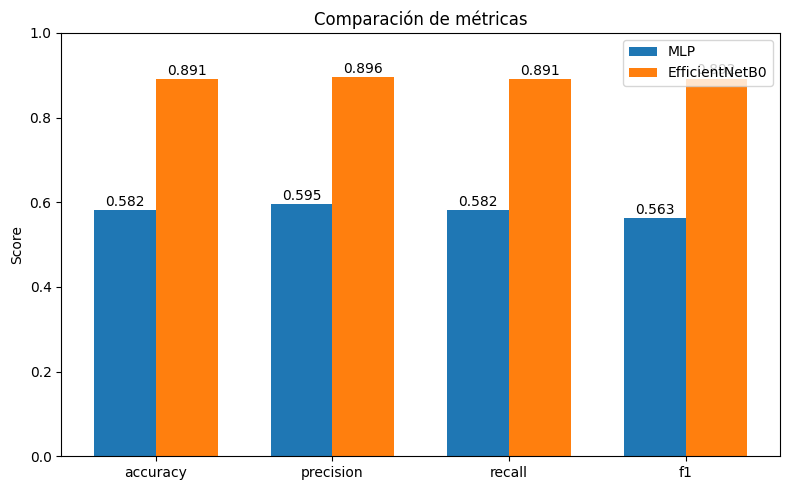

In [5]:
compare_df = pd.DataFrame({
    'Métrica': ['accuracy', 'precision', 'recall', 'f1'],
    'MLP': [mlp_metrics['accuracy'], mlp_metrics['precision'], mlp_metrics['recall'], mlp_metrics['f1']],
    'EfficientNetB0': [dl_metrics['accuracy'], dl_metrics['precision'], dl_metrics['recall'], dl_metrics['f1']]
})

compare_df['Diferencia'] = compare_df['EfficientNetB0'] - compare_df['MLP']
print(compare_df)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ix = np.arange(len(compare_df))
width = 0.35
ax.bar(ix - width/2, compare_df['MLP'], width, label='MLP')
ax.bar(ix + width/2, compare_df['EfficientNetB0'], width, label='EfficientNetB0')
ax.set_xticks(ix)
ax.set_xticklabels(compare_df['Métrica'])
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Comparación de métricas')
ax.legend()

for i, v in enumerate(compare_df['MLP']):
    ax.text(i - width/2, v + 0.01, f'{v:.3f}', ha='center')
for i, v in enumerate(compare_df['EfficientNetB0']):
    ax.text(i + width/2, v + 0.01, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.show()

## 5. Matrices de confusión

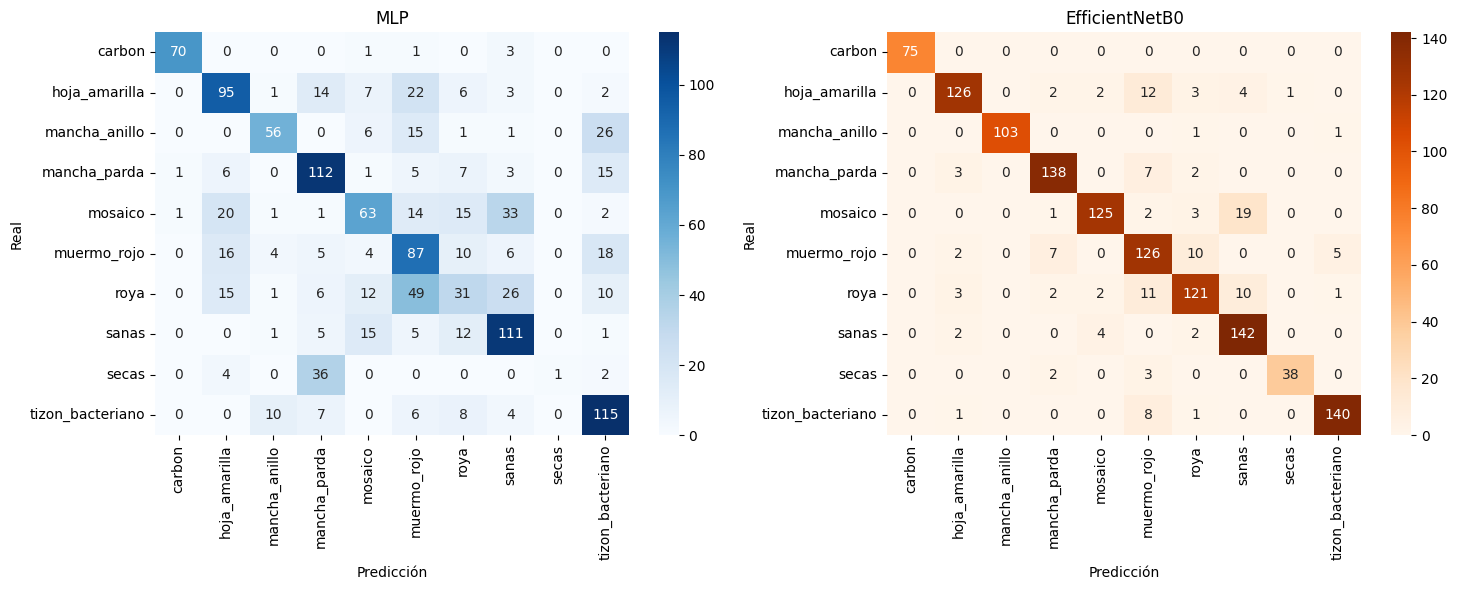

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.heatmap(mlp_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=class_names, yticklabels=class_names)
axes[0].set_title('MLP')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')

sns.heatmap(dl_cm, annot=True, fmt='d', cmap='Oranges', ax=axes[1], xticklabels=class_names, yticklabels=class_names)
axes[1].set_title('EfficientNetB0')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()